# Datos

In [4]:
from pathlib import Path
import os
import re
import pandas as pd
import SimpleITK as sitk 

In [5]:
# 1. Ruta a tu carpeta raíz
ROOT = Path("../../data/images")
os.makedirs("datos_intermedios", exist_ok=True)

rows = []

for study_dir in ROOT.iterdir():
    if not study_dir.is_dir():
        continue

    row = {
        "patient_id": None,
        "study_id":  None,
        "t2w_height": None, "t2w_width": None, "t2w_depth": None,
        "dwi_height": None, "dwi_width": None, "dwi_depth": None,
        "adc_height": None, "adc_width": None, "adc_depth": None,
    }

    for f in study_dir.glob("*.mha"):
        stem = f.stem          
        parts = stem.split("_")

        # Detectar patient_id y study_id solo una vez
        if row["patient_id"] is None and len(parts) >= 2:
            row["patient_id"], row["study_id"] = parts[0], parts[1]

        seq = parts[-1].lower()      

        if seq == "t2w" or seq == "hbv" or seq == "adc":
            img  = sitk.ReadImage(str(f))
            w,h,d = img.GetSize()    # SimpleITK da (width, height, depth)
            if seq == "t2w":
                row.update({"t2w_height": h, "t2w_width": w, "t2w_depth": d})
            elif seq == "hbv":
                row.update({"dwi_height": h, "dwi_width": w, "dwi_depth": d})
            elif seq == "adc":
                row.update({"adc_height": h, "adc_width": w, "adc_depth": d})

    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("datos_intermedios/image_dimensions.csv", index=False)

# Gráfico

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  
import seaborn as sns
import scienceplots                 

plt.style.use(['science', 'grid'])  

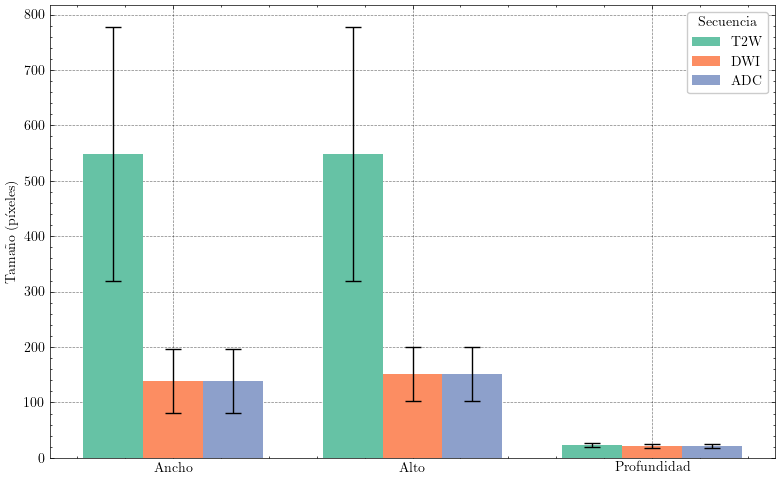

In [4]:
# 1. Cargar el CSV con las dimensiones
csv_path = Path("datos_intermedios/image_dimensions.csv")
df = pd.read_csv(csv_path)

# 2. Definir secuencias y dimensiones
secuencias = ["t2w", "dwi", "adc"]
dimensiones = ["width", "height", "depth"]
col_tpl = "{seq}_{dim}"

# 3. Calcular medias y desviaciones
medias, desv = [], []
for dim in dimensiones:
    medias.append([df[col_tpl.format(seq=s, dim=dim)].mean() for s in secuencias])
    desv.append(  [df[col_tpl.format(seq=s, dim=dim)].std()  for s in secuencias])

medias = np.array(medias)   # (3,3)
desv   = np.array(desv)

# 4. Configurar la paleta color-blind-friendly
palette = sns.color_palette("Set2", n_colors=len(secuencias))
colores = dict(zip(secuencias, palette))

# ─────────────────────────────────────────────────────────
# 5. Dibujar las barras
x       = np.arange(len(dimensiones))   
ancho   = 0.25
offsets = [-ancho, 0, ancho]

fig, ax = plt.subplots(figsize=(8, 5))

for i, seq in enumerate(secuencias):
    ax.bar(
        x + offsets[i],
        medias[:, i],
        ancho,
        yerr=desv[:, i],
        capsize=6,
        label=seq.upper(),
        color=colores[seq]              
    )

# 6. Etiquetas en castellano
ax.set_xticks(x)
ax.set_xticklabels(['Ancho', 'Alto', 'Profundidad'])
ax.set_ylabel('Tamaño (píxeles)')
ax.legend(title='Secuencia')

fig.tight_layout()
fig.savefig("results/tamaño_por_secuencia.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_633/1291816002.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_633/1291816002.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_633/1291816002.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


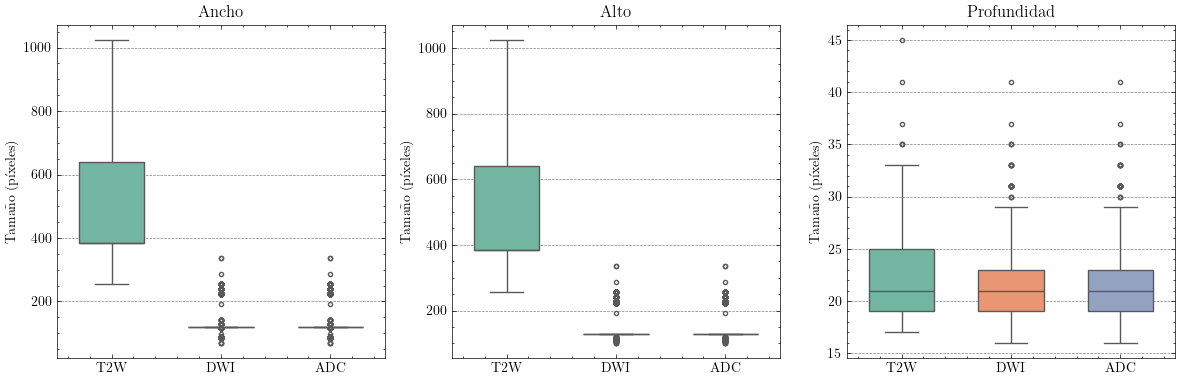

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

# 1. Leer datos y preparar long-form (igual que antes)
csv_path   = Path("datos_intermedios/image_dimensions.csv")
df         = pd.read_csv(csv_path)

secuencias   = ["t2w", "dwi", "adc"]
dimensiones  = ["width", "height", "depth"]
dim_español  = {"width": "Ancho", "height": "Alto", "depth": "Profundidad"}

registros = []
for seq in secuencias:
    for dim in dimensiones:
        registros.append(pd.DataFrame({
            "Secuencia": seq.upper(),
            "Dimensión": dim_español[dim],
            "Valor":     df[f"{seq}_{dim}"]
        }))
df_long = pd.concat(registros, ignore_index=True)

# 2. Estilo y paleta
plt.style.use(['science', 'grid'])
palette = sns.color_palette("Set2", n_colors=len(secuencias))

# 3. Crear una fila de subgráficos
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for i, dim in enumerate(dimensiones):
    ax = axes[i]
    sns.boxplot(
        data   = df_long[df_long["Dimensión"] == dim_español[dim]],
        x      = "Secuencia",
        y      = "Valor",
        palette= palette,
        ax     = ax,
        width  = 0.6,
        fliersize = 3
    )
    ax.set_title(dim_español[dim])
    ax.set_xlabel("")
    ax.set_ylabel("Tamaño (píxeles)")

fig.tight_layout()
# fig.savefig("results/tamaño_por_dimensión_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()